In [233]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import cross_val_score

import shap

In [195]:
file_path =  r"C:\Users\Yasindu\Desktop\Stuff\Research\Datasets\PrePROCESSED DATA\pre_processed_data2.csv"
data = pd.read_csv(file_path)
data.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10_Autism_Spectrum_Quotient,Age_in_Months,Sex_M,Jaundice_Yes,Family_mem_with_ASD_Yes,Who_completed_the_test_Health Care Professional,Who_completed_the_test_Others,Who_completed_the_test_School and NGO,ASD_traits_Yes
0,0,0,0,0,0,0,1,1,0,1,-0.761438,False,True,False,False,False,False,False
1,1,1,0,0,0,1,1,0,0,0,-0.382003,True,True,False,False,False,False,True
2,1,0,0,0,0,0,1,1,0,1,-0.382003,True,True,False,False,False,False,True
3,1,1,1,1,1,1,1,1,1,1,-0.761438,True,False,False,False,False,False,True
4,1,1,0,1,1,1,1,1,1,1,-1.140874,False,False,True,False,False,False,True


In [196]:
print(data.columns)

Index(['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9',
       'A10_Autism_Spectrum_Quotient', 'Age_in_Months', 'Sex_M',
       'Jaundice_Yes', 'Family_mem_with_ASD_Yes',
       'Who_completed_the_test_Health Care Professional',
       'Who_completed_the_test_Others',
       'Who_completed_the_test_School and NGO', 'ASD_traits_Yes'],
      dtype='object')


In [198]:
# Step 1: Train-Test Split
X = data.drop(columns=['ASD_traits_Yes'])  # Features
y = data['ASD_traits_Yes']  # Target variable

# Split data into training and testing sets (80% train, 20% test)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [199]:
# Step 2: Logistic Regression Model
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X_test)


In [200]:
# Step 3: Random Forest Classifier Model
from sklearn.ensemble import RandomForestClassifier
random_forest = RandomForestClassifier(random_state=42)
random_forest.fit(X_train, y_train)
y_pred_rf = random_forest.predict(X_test)


In [201]:
# Step 4: Evaluate Models

# Logistic Regression Evaluation

print("Logistic Regression Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg)}")
print(f"Precision: {precision_score(y_test, y_pred_log_reg)}")
print(f"Recall: {recall_score(y_test, y_pred_log_reg)}")
print(f"F1 Score: {f1_score(y_test, y_pred_log_reg)}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_log_reg)}\n")

# Random Forest Evaluation
print("Random Forest Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)}")
print(f"Precision: {precision_score(y_test, y_pred_rf)}")
print(f"Recall: {recall_score(y_test, y_pred_rf)}")
print(f"F1 Score: {f1_score(y_test, y_pred_rf)}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_rf)}\n")

Logistic Regression Evaluation:
Accuracy: 0.9324324324324325
Precision: 0.9468599033816425
Recall: 0.9560975609756097
F1 Score: 0.9514563106796117
ROC-AUC: 0.9176092200482444

Random Forest Evaluation:
Accuracy: 0.9425675675675675
Precision: 0.9563106796116505
Recall: 0.9609756097560975
F1 Score: 0.9586374695863747
ROC-AUC: 0.9310372554274993



In [202]:
# Logistic Regression Cross-Validation
log_reg_cv = cross_val_score(log_reg, X, y, cv=5, scoring='accuracy')
print(f"Logistic Regression Cross-Validation Accuracy: {log_reg_cv.mean()}")

# Random Forest Cross-Validation
rf_cv = cross_val_score(random_forest, X, y, cv=5, scoring='accuracy')
print(f"Random Forest Cross-Validation Accuracy: {rf_cv.mean()}")

Logistic Regression Cross-Validation Accuracy: 0.9112780577187356
Random Forest Cross-Validation Accuracy: 0.9404260192395786


In [203]:
# Get the feature importance from the trained Random Forest model
feature_importance = random_forest.feature_importances_

In [204]:
# Create a DataFrame to pair feature names with their importance scores
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
})

In [205]:
# Sort the features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

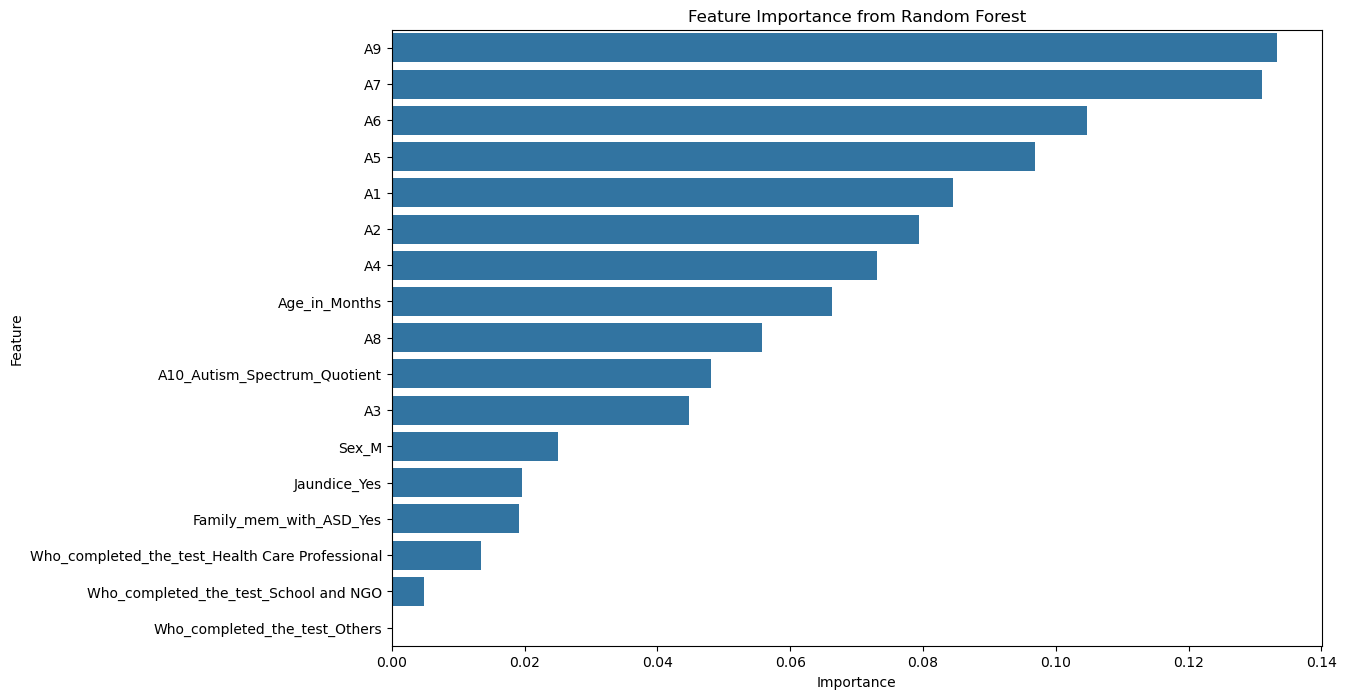

In [206]:
# Plot the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance from Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


In [207]:
# Print the sorted feature importance
print(importance_df)

                                            Feature  Importance
8                                                A9    0.133402
6                                                A7    0.131040
5                                                A6    0.104647
4                                                A5    0.096923
0                                                A1    0.084541
1                                                A2    0.079366
3                                                A4    0.073053
10                                    Age_in_Months    0.066318
7                                                A8    0.055800
9                      A10_Autism_Spectrum_Quotient    0.048040
2                                                A3    0.044693
11                                            Sex_M    0.024964
12                                     Jaundice_Yes    0.019585
13                          Family_mem_with_ASD_Yes    0.019131
14  Who_completed_the_test_Health Care P

In [208]:
# Train XGBoost Classifier|
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

# Evaluate XGBoost Model
print("XGBoost Evaluation:")
y_pred_xgb = xgb.predict(X_test)  # Make predictions
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb)}")
print(f"Precision: {precision_score(y_test, y_pred_xgb)}")
print(f"Recall: {recall_score(y_test, y_pred_xgb)}")
print(f"F1 Score: {f1_score(y_test, y_pred_xgb)}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_xgb)}\n")

XGBoost Evaluation:
Accuracy: 0.9594594594594594
Precision: 0.9753694581280788
Recall: 0.9658536585365853
F1 Score: 0.9705882352941176
ROC-AUC: 0.9554543017957652



In [209]:
# Cross-validation for XGBoost
xgb_cv = cross_val_score(xgb, X, y, cv=5, scoring='accuracy')
print(f"XGBoost Cross-Validation Accuracy: {xgb_cv.mean()}")

XGBoost Cross-Validation Accuracy: 0.9546197892808062


In [210]:
# Train Support Vector Machine (SVM)
svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

In [211]:
# Evaluate SVM Model
print("SVM Evaluation:")
y_pred_svm = svm.predict(X_test)  # Make predictions
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm)}")
print(f"Precision: {precision_score(y_test, y_pred_svm)}")
print(f"Recall: {recall_score(y_test, y_pred_svm)}")
print(f"F1 Score: {f1_score(y_test, y_pred_svm)}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_svm)}\n")


SVM Evaluation:
Accuracy: 0.9527027027027027
Precision: 0.9751243781094527
Recall: 0.9560975609756097
F1 Score: 0.9655172413793104
ROC-AUC: 0.9505762530152774



In [212]:
# Cross-validation for SVM
svm_cv = cross_val_score(svm, X, y, cv=10, scoring='accuracy')
print(f"SVM Cross-Validation Accuracy: {svm_cv.mean()}")

SVM Cross-Validation Accuracy: 0.9463917999632286


In [235]:
# For XGBoost (replace with your XGBoost model)
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)


# For Random Forest (replace with your Random Forest model)
explainer_rf = shap.TreeExplainer(random_forest)
shap_values_rf = explainer_rf.shap_values(X_test)


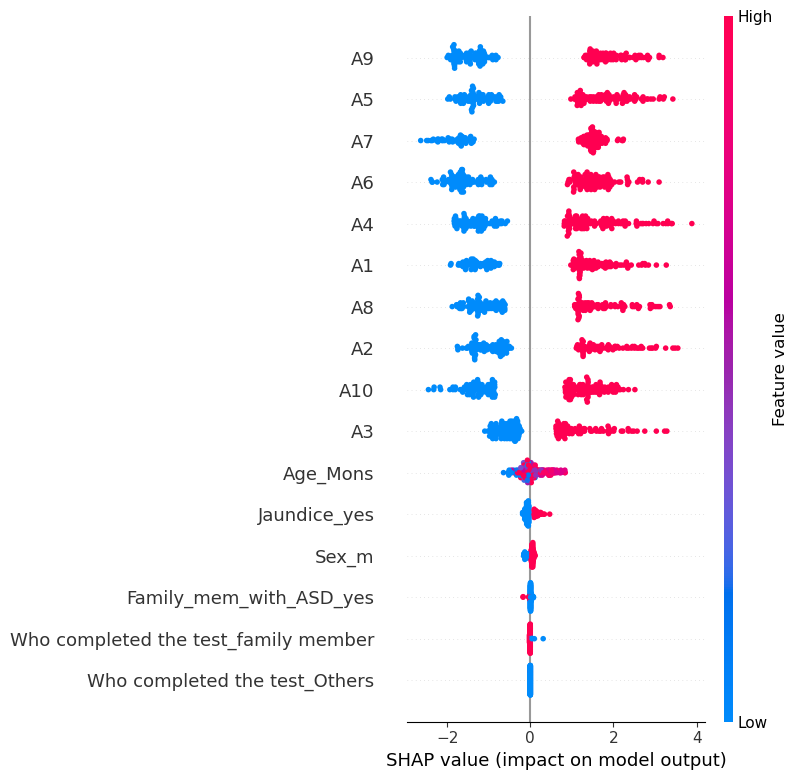

In [236]:

# Plot the SHAP summary plot
shap.summary_plot(shap_values, X_test)

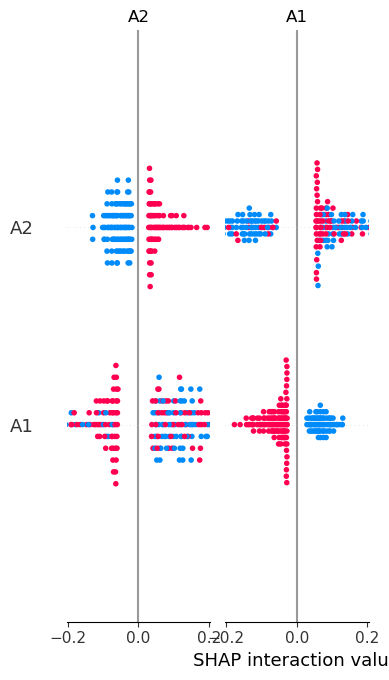

In [237]:

# Plot the SHAP summary plot for Random Forest
shap.summary_plot(shap_values_rf, X_test)